# **Single class sensitivity analysis: what the classifying layer may show**

## Navigation

- [**Basic imports and initialization**](#Basic-imports-and-initialization)
- [**1. Alexnet**](#1.-Alexnet)
- [**2. ResNet18**](#2.-ResNet18)

## Basic imports and initialization

$\qquad$ [[Back to top]](#Navigation) $\qquad$ [[Next part $\to$]](#1.-Alexnet)

- [Setting up templates, limiting the hardware resources, importing packages](#Setting-up-templates,-limiting-the-hardware-resources,-importing-packages)
- [Initializing common variables](#Initializing-common-variables)
- [Configuring experiments and generating corresponding sh-files](#Configuring-experiments-and-generating-corresponding-sh-files)

### Setting up templates, limiting the hardware resources, importing packages

$\quad$[[Back to section]](#Basic-imports-and-initialization)$\quad$[[Next subsect.$\to$]](#Initializing-common-variables)

In [1]:
notebook_directory_offset = '../'
libstdcpp_path = ''

In the case of problems with loading ```libstc++.so.6```, please provide the path to the library. In any other case, just ignore the following block.

In [2]:
import ctypes

libstdcpp_path = '/mnt/bulky/pkharyuk/apd/envs/activation_sense/lib/libstdc++.so.6'
try:
    _stdcxx_lib = ctypes.cdll.LoadLibrary(libstdcpp_path)
except:
    pass

To provide easy access to modules stored in the ```../src/``` directory, we use the following workaround:

In [2]:
import os
import sys
sys.path.append(
    os.path.join(notebook_directory_offset, '../src/')
)

Next, we limit the hardware usage by setting the configuration dictionaries, maximum number of threads:

In [3]:
# set limitations on hardware
# fill on the template's config
import hardware_setup

mkl_num_threads = 4
hardware_setup.mkl_set_num_threads(num_threads=mkl_num_threads)

[mkl]: set up num_threads=4/4


Then we import all necessary packages:

In [4]:
import functools

import numpy as np

import sensitivity_analysis.augmentation_setting
import preparation.single_unit
import prediction.compute
import prediction.single_class
import data_loader.places365

import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display

### Initializing common variables

[[$\leftarrow$Prev.subsect.]](#Setting-up-templates,-limiting-the-hardware-resources,-importing-packages)$\quad$[[Back to section]](#Basic-imports-and-initialization)$\quad$[[Next subsect.$\to$]](#Configuring-experiments-and-generating-corresponding-sh-files)

In [6]:
dataset_name = 'places365'
data_dirname = f'../data/{dataset_name}'

sensitivity_values_dirname = '../results/'
results_dirname = '../results/'

values_fnm_base = f'{dataset_name}_values'

no_aug_key = 'original'
y_true_key = 'true_labels'

n_round_digits = 4

alphas = (0., 0.5, 1.5)
percentiles = (0.5, 0.6, 0.7, 0.8, 0.9)
inverts = (0, 1)

augmentation_set_numbers_list = (1, 2)

n_top_values_decay_plot = 20
figsize_decay_plot = (10, 5)

In [6]:
places365_dataset = data_loader.places365.CustomPlaces365(
    os.path.join(
        notebook_directory_offset,
        data_dirname
    ),
    split='val'
)

In [7]:
shpv_group_indices_dict = {}
for aug_set_num in augmentation_set_numbers_list:
    shpv_group_indices_dict[
        aug_set_num
    ] = sensitivity_analysis.augmentation_setting.get_group_variables_indices(
        aug_set_num,
        use_permutation_variable=1,
        use_class_variable=1,
        use_partition_variable=1,
    )

sensitivity_values_name_list = [
    'shpv', 'si'
]
n_sens_vals = len(sensitivity_values_name_list)

augmentation_names_dict = preparation.single_unit.extract_augmentation_names_dict(
    augmentation_set_numbers_list,
    extract_auxilliary_names=False,
)
augmentation_names = functools.reduce(
    lambda x, y: x+y, augmentation_names_dict.values()
)

## 1. Alexnet

[[$\leftarrow$ Prev.part]](#Basic-imports-and-initialization) $\qquad$ [[Back to top]](#Navigation) $\qquad$ [[Next part $\to$]](#2.-ResNet18)


- [1.1 Set up variables](#1.1-Set-up-variables)
- [1.2 Decay of the top sensitivity values](#1.2-Decay-of-the-top-sensitivity-values)
- [1.3 Top sensitivity values and corresponding classes](#1.3-Top-sensitivity-values-and-corresponding-classes)
- [1.4 Jaccard indices for top-5 predictions and top-5 sensitive classes](#1.4-Jaccard-indices-for-top-5-predictions-and-top-5-sensitive-classes)
- [1.5 Jaccard indices for top-5 masked predictions and top-5 sensitive classes](#1.5-Jaccard-indices-for-top-5-masked-predictions-and-top-5-sensitive-classes)

### 1.1 Set up variables

$\quad$[[Back to section]](#1.-Alexnet)$\quad$[[Next subsect.$\to$]](#1.2-Decay-of-the-top-sensitivity-values)

In [10]:
alexnet_network_name = 'alexnet'
alexnet_classifying_layer_name = 'classifier.6'

prediction_results_path_nofcl_list = [
    os.path.join(
        notebook_directory_offset,
        results_dirname,
        f'{val_name}_{alexnet_network_name}_{values_fnm_base}_pred_NOFCL_part=valid.hdf5'
    ) for val_name in sensitivity_values_name_list
]

alexnet_values_fnms_dict = preparation.single_unit.extract_massive_values_fnms(
    alexnet_network_name,
    values_fnm_base,
    augmentation_set_numbers_list,
    prefix=None
);

alexnet_loaded_sensitivity_values_dict_list = []
for sensitivity_values_name in sensitivity_values_name_list:
    loaded_sensitivity_values_dict = prediction.compute.get_all_values(
        alexnet_values_fnms_dict,
        os.path.join(notebook_directory_offset, results_dirname),
        [alexnet_classifying_layer_name],
        sensitivity_values_name,
        augmentation_set_numbers_list,
        shpv_group_indices_dict,
        extract_auxilliary_names=False,
    )
    alexnet_loaded_sensitivity_values_dict_list.append(
        loaded_sensitivity_values_dict
    )

### 1.2 Decay of the top sensitivity values

[[$\leftarrow$Prev.subsect.]](#1.1-Set-up-variables)$\quad$[[Back to section]](#1.-Alexnet)$\quad$[[Next subsect.$\to$]](#1.3-Top-sensitivity-values-and-corresponding-classes)

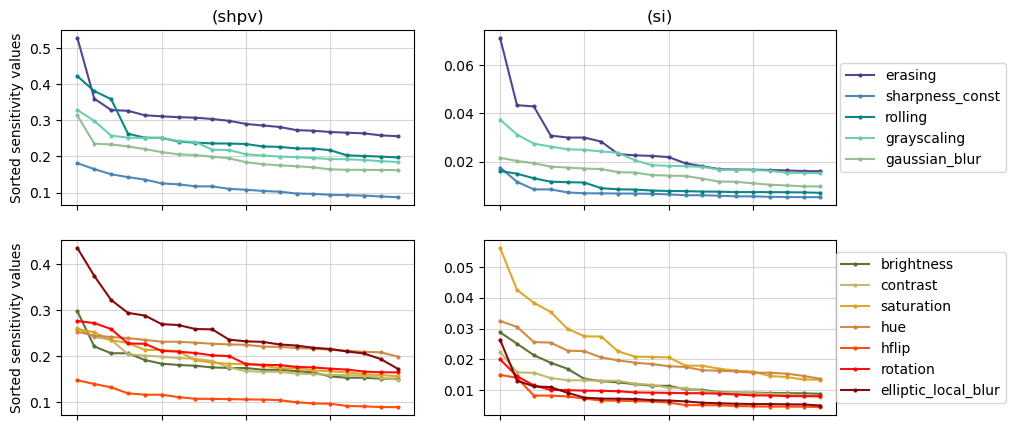

In [11]:
prediction.single_class.plot_top_sensitivity_values_decay(
    alexnet_loaded_sensitivity_values_dict_list,
    alexnet_classifying_layer_name,
    sensitivity_values_name_list,
    augmentation_set_numbers_list,
    n_top_values=n_top_values_decay_plot,
    figsize=figsize_decay_plot,
    extract_auxilliary_names=False,
    plot_colors=prediction.single_class._custom_colors[::-1],
    show=True,
)

### 1.3 Top sensitivity values and corresponding classes

[[$\leftarrow$Prev.subsect.]](#1.2-Decay-of-the-top-sensitivity-values)$\quad$[[Back to section]](#1.-Alexnet)$\quad$[[Next subsect.$\to$]](#1.4-Jaccard-indices-for-top-5-predictions-and-top-5-sensitive-classes)

In [12]:
table_dict = prediction.single_class.extract_tables_top_sensitivity_values_decay(
    alexnet_loaded_sensitivity_values_dict_list,
    alexnet_classifying_layer_name,
    sensitivity_values_name_list,
    augmentation_set_numbers_list,
    places365_dataset.ind2class,
    n_top_values=10,
    extract_auxilliary_names=False,
)

In [13]:
for aug_name in augmentation_names:
    print(f'\n\t\t\t Augmentation: {aug_name}')
    display(table_dict[aug_name])


			 Augmentation: erasing


shpv                                si                            
  class_id         class_name value class_id            class_name value
0      249            orchard   .53      177          home_theater   .07
1      330        temple asia   .36      235  movie_theater indoor   .04
2      348            village   .33      328       television_room   .04
3      165  greenhouse indoor   .33      263           phone_booth   .03
4       53        beer_garden   .31       41              barndoor   .03
5      261           pet_shop   .31      216          loading_dock   .03
6       69     burial_chamber   .31      129         elevator door   .03
7       46      bazaar indoor   .31      280             reception   .02
8      193        inn outdoor   .30      332          ticket_booth   .02
9      233      mountain_path   .30      133           engine_room   .02


			 Augmentation: sharpness_const


shpv                                 si                         
  class_id          class_name value class_id         class_name value
0      114        delicatessen   .18      231              motel   .02
1       47      bazaar outdoor   .16      141         field wild   .01
2      136          excavation   .15       67    building_facade   .01
3       20          art_school   .14       34           ball_pit   .01
4      209                lawn   .14       79        canal urban   .01
5      151         forest_path   .13      329  television_studio   .01
6      200              kasbah   .12      129      elevator door   .01
7      166  greenhouse outdoor   .12        0           airfield   .01
8      118         desert_road   .12       38       banquet_hall   .01
9        6    amusement_arcade   .11      304         ski_resort   .01


			 Augmentation: rolling


...

shpv                                    si                      
  class_id             class_name value class_id      class_name value
0      294                sandbox   .15       43        basement   .01
1      160   general_store indoor   .14      152     forest_road   .01
2      145               fishpond   .13       80     candy_store   .01
3      340                 trench   .12       90   church indoor   .01
4      219            locker_room   .12      317       staircase   .01
5      217                  lobby   .12      258         pasture   .01
6      326  swimming_pool outdoor   .11      305       ski_slope   .01
7       90          church indoor   .11      316   stage outdoor   .01
8      141             field wild   .11      230  mosque outdoor   .01
9      236          museum indoor   .11      128       drugstore   .01


			 Augmentation: rotation


shpv                               si                          
  class_id        class_name value class_id          class_name value
0      127          driveway   .28      319              street   .02
1       58         boat_deck   .27      164         golf_course   .01
2       77            campus   .26      332        ticket_booth   .01
3       96    clothing_store   .23       25       atrium public   .01
4       31       bakery shop   .23      140    field cultivated   .01
5      291       rope_bridge   .21      100       computer_room   .01
6      246   office_cubicles   .21      162           gift_shop   .01
7       14           archive   .21       56  biology_laboratory   .01
8      177      home_theater   .20      244              office   .01
9      286  restaurant_patio   .20      183               house   .01


			 Augmentation: elliptic_local_blur


shpv                                   si                     
  class_id            class_name value class_id     class_name value
0      155                galley   .43       54      beer_hall   .03
1      241          nursing_home   .37      152    forest_road   .01
2      134         entrance_hall   .32      287     rice_paddy   .01
3      203               kitchen   .29      316  stage outdoor   .01
4      160  general_store indoor   .29      291    rope_bridge   .01
5      173              hayfield   .27      215    living_room   .01
6      113                   dam   .27      177   home_theater   .01
7      221     manufactured_home   .26      143    fire_escape   .01
8        1        airplane_cabin   .26      109      courtyard   .01
9      262              pharmacy   .24       88  chemistry_lab   .01

### 1.4 Jaccard indices for top-5 predictions and top-5 sensitive classes

[[$\leftarrow$Prev.subsect.]](#1.3-Top-sensitivity-values-and-corresponding-classes)$\quad$[[Back to section]](#1.-Alexnet)$\quad$[[Next subsect.$\to$]](#1.5-Jaccard-indices-for-top-5-masked-predictions-and-top-5-sensitive-classes)

In [14]:
alexnet_sensitivity_topn_list = prediction.single_class.get_sensitivity_topn_dict(
    alexnet_loaded_sensitivity_values_dict_list,
    alexnet_classifying_layer_name,
    augmentation_set_numbers_list,
    top_n=5,
    extract_auxilliary_names=False,
)

alexnet_results_jacc_nofcl_list = []
alexnet_results_jacc_aug_no_mask_list = []
alexnet_results_jacc_orig_no_mask_list = []

for i in range(n_sens_vals):
    (
        alexnet_results_jacc, 
        alexnet_results_jacc_aug_no_mask,
        alexnet_results_jacc_orig_no_mask,
    ) = prediction.single_class.extract_jaccard(
        prediction_results_path_nofcl_list[i],
        alexnet_sensitivity_topn_list[i],
        augmentation_names,
        no_aug_key=no_aug_key,
        y_true_key=y_true_key,
    )
    alexnet_results_jacc_nofcl_list.append(alexnet_results_jacc)
    alexnet_results_jacc_aug_no_mask_list.append(alexnet_results_jacc_aug_no_mask)
    alexnet_results_jacc_orig_no_mask_list.append(alexnet_results_jacc_orig_no_mask)

Nsamples=36500
Nsamples=36500


In [15]:
for i_val, val_name in enumerate(sensitivity_values_name_list):
    table_jac_no_masking = prediction.single_class.extract_table_no_masking(
        alexnet_results_jacc_aug_no_mask_list[i_val],
        alexnet_results_jacc_orig_no_mask_list[i_val],
        augmentation_set_numbers_list,
        extract_auxilliary_names=False,
        n_round_digits=n_round_digits,
        no_aug_key=no_aug_key,
    )
    print(f'\n\n\t\t\t\t{val_name}')
    display(table_jac_no_masking)



				shpv


SA variable used for extracting the most sensitive classes from the classifying layer   
                                                                                                    erasing   
Augmentation of input                                                                                         
original                                                          0.0071                                     \
erasing                                                           0.0040                                      
sharpness_const                                                   0.0071                                      
rolling                                                           0.0061                                      
grayscaling                                                       0.0043                                      
gaussian_blur                                                     0.0069                                      
brightness                                                        0.0075                                      
contrast                                                          0.0074                                      
saturation                                                        0.0060                                      
hue                                                               0.0077                                      
hflip                                                             0.0071                                      
rotation                                                          0.0085                                      
elliptic_local_blur                                               0.0069                                      

                                                                          
                      sharpness_const rolling grayscaling gaussian_blur   
Augmentation of input                                                     
original                       0.0079  0.0068      0.0070        0.0082  \
erasing                        0.0063  0.0033      0.0051        0.0085   
sharpness_const                0.0074  0.0068      0.0065        0.0082   
rolling                        0.0079  0.0053      0.0065        0.0084   
grayscaling                    0.0021  0.0054      0.0019        0.0061   
gaussian_blur                  0.0078  0.0068      0.0069        0.0076   
brightness                     0.0083  0.0071      0.0068        0.0109   
contrast                       0.0071  0.0060      0.0060        0.0082   
saturation                     0.0066  0.0074      0.0063        0.0083   
hue                            0.0043  0.0066      0.0077        0.0113   
hflip                          0.0079  0.0068      0.0071        0.0083   
rotation                       0.0103  0.0075      0.0102        0.0079   
elliptic_local_blur            0.0076  0.0069      0.0069        0.0082   

                                                                                
                      brightness contrast saturation     hue   hflip rotation   
Augmentation of input                                                           
original                  0.0074   0.0075     0.0074  0.0083  0.0066   0.0087  \
erasing                   0.0070   0.0046     0.0071  0.0088  0.0055   0.0089   
sharpness_const           0.0077   0.0072     0.0072  0.0083  0.0061   0.0089   
rolling                   0.0072   0.0065     0.0078  0.0083  0.0072   0.0089   
grayscaling               0.0058   0.0071     0.0097  0.0090  0.0071   0.0052   
gaussian_blur             0.0070   0.0075     0.0063  0.0080  0.0068   0.0076   
brightness                0.0101   0.0066     0.0059  0.0070  0.0059   0.0090   
contrast                  0.0068   0.0058     0.0051  0.0083  0.0059   0.0082   
saturation                0.0080   0.0063     0.0055  0.0086  0.0062   0.0073   
hue                       0.0094   0.0050     0.0035  0.0066  0.0057   0



				si


SA variable used for extracting the most sensitive classes from the classifying layer   
                                                                                                    erasing   
Augmentation of input                                                                                         
original                                                          0.0067                                     \
erasing                                                           0.0328                                      
sharpness_const                                                   0.0067                                      
rolling                                                           0.0076                                      
grayscaling                                                       0.0058                                      
gaussian_blur                                                     0.0076                                      
brightness                                                        0.0063                                      
contrast                                                          0.0089                                      
saturation                                                        0.0069                                      
hue                                                               0.0081                                      
hflip                                                             0.0068                                      
rotation                                                          0.0048                                      
elliptic_local_blur                                               0.0066                                      

                                                                          
                      sharpness_const rolling grayscaling gaussian_blur   
Augmentation of input                                                     
original                       0.0064  0.0065      0.0097        0.0081  \
erasing                        0.0054  0.0109      0.0104        0.0217   
sharpness_const                0.0063  0.0064      0.0111        0.0085   
rolling                        0.0061  0.0075      0.0109        0.0081   
grayscaling                    0.0068  0.0046      0.0242        0.0074   
gaussian_blur                  0.0080  0.0077      0.0075        0.0061   
brightness                     0.0065  0.0073      0.0091        0.0079   
contrast                       0.0069  0.0073      0.0111        0.0089   
saturation                     0.0096  0.0071      0.0088        0.0088   
hue                            0.0061  0.0060      0.0099        0.0074   
hflip                          0.0063  0.0065      0.0098        0.0080   
rotation                       0.0058  0.0059      0.0070        0.0077   
elliptic_local_blur            0.0064  0.0067      0.0098        0.0079   

                                                                                
                      brightness contrast saturation     hue   hflip rotation   
Augmentation of input                                                           
original                  0.0088   0.0100     0.0070  0.0100  0.0077   0.0079  \
erasing                   0.0071   0.0152     0.0071  0.0071  0.0059   0.0092   
sharpness_const           0.0084   0.0111     0.0068  0.0100  0.0077   0.0080   
rolling                   0.0090   0.0118     0.0079  0.0099  0.0078   0.0072   
grayscaling               0.0035   0.0116     0.0112  0.0037  0.0078   0.0097   
gaussian_blur             0.0095   0.0089     0.0081  0.0093  0.0071   0.0090   
brightness                0.0167   0.0138     0.0094  0.0108  0.0075   0.0087   
contrast                  0.0093   0.0200     0.0093  0.0133  0.0070   0.0085   
saturation                0.0174   0.0162     0.0125  0.0114  0.0089   0.0094   
hue                       0.0111   0.0198     0.0117  0.0193  0.0064   0

### 1.5 Jaccard indices for top-5 masked predictions and top-5 sensitive classes

[[$\leftarrow$Prev.subsect.]](#1.4-Jaccard-indices-for-top-5-predictions-and-top-5-sensitive-classes)$\quad$[[Back to section]](#1.-Alexnet)$\quad$

In [16]:
for i_val, val_name in enumerate(sensitivity_values_name_list):
    featured_measurements, _ = prediction.single_class.collect_featured_measurements_jac(
        alexnet_results_jacc_nofcl_list[i_val],
        augmentation_set_numbers_list,
        alphas,
        percentiles,
        inverts,
        no_aug_key=no_aug_key,
    )
    table = prediction.single_class.extract_table_self_masking(
        featured_measurements,
        augmentation_set_numbers_list,
        alphas,
        percentiles,
        inverts,
        n_round_digits=n_round_digits,
        extract_auxilliary_names=False,
    )
    print(f'\n\n\t\t\t\t{val_name}')
    display(table)



				shpv


Mask configuration (SA variable is the same as augmentation)   
                                                                         alpha=0.0   
                                                                             q=0.5   
Augmentation of input                                                                
erasing                                                           0.0000            \
sharpness_const                                                   0.0000             
rolling                                                           0.1111             
grayscaling                                                       0.0000             
gaussian_blur                                                     0.0000             
brightness                                                        0.0000             
contrast                                                          0.0000             
saturation                                                        0.0000             
hue                                                               0.0000             
hflip                                                             0.0000             
rotation                                                          0.0000             
elliptic_local_blur                                               0.0000             

                                                                          
                                                      alpha=0.5           
                        q=0.6   q=0.7   q=0.8   q=0.9     q=0.5   q=0.6   
Augmentation of input                                                     
erasing                0.0000  0.0354  0.0292  0.0126    0.0133  0.0125  \
sharpness_const        0.0000  0.0000  0.0000  0.0008    0.0144  0.0107   
rolling                0.1111  0.0000  0.0051  0.0087    0.0093  0.0092   
grayscaling            0.0000  0.0000  0.0000  0.0002    0.0001  0.0004   
gaussian_blur          0.0000  0.0000  0.0423  0.0145    0.0035  0.0035   
brightness             0.0000  0.0400  0.0122  0.0089    0.0041  0.0048   
contrast               0.0000  0.0000  0.0000  0.0014    0.0063  0.0072   
saturation             0.0000  0.0008  0.0092  0.0130    0.0118  0.0131   
hue                    0.0000  0.0000  0.0017  0.0118    0.0129  0.0107   
hflip                  0.0000  0.0000  0.0000  0.0001    0.0093  0.0093   
rotation               0.1111  0.0056  0.0008  0.0028    0.0036  0.0035   
elliptic_local_blur    0.0000  0.0000  0.0000  0.0038    0.0016  0.0017   

                                                                          
                                              alpha=1.5                   
                        q=0.7   q=0.8   q=0.9     q=0.5   q=0.6   q=0.7   
Augmentation of input                                                     
erasing                0.0157  0.0124  0.0083    0.0016  0.0014  0.0010  \
sharpness_const        0.0094  0.0067  0.0067    0.0109  0.0092  0.0086   
rolling                0.0107  0.0101  0.0087    0.0029  0.0028  0.0024   
grayscaling            0.0007  0.0002  0.0009    0.0016  0.0014  0.0017   
gaussian_blur          0.0051  0.0143  0.0091    0.0069  0.0069  0.0066   
brightness             0.0073  0.0089  0.0092    0.0123  0.0126  0.0124   
contrast               0.0049  0.0039  0.0060    0.0029  0.0027  0.0027   
saturation             0.0141  0.0094  0.0105    0.0028  0.0027  0.0025   
hue                    0.0061  0.0075  0.0094    0.0056  0.0056  0.0049   
hflip                  0.0089  0.0054  0.0049    0.0055  0.0057  0.0064   
rotation               0.0034  0.0034  0.0060    0.0092  0.0091  0.0092   
elliptic_local_blur    0.0030  0.0041  0.0070    0.0064  0.0067  0.0080   

                                                       
                                        inv=0   inv=1  
                        q=0.8   q=0.9                  
Augmentation of input                                  
erasing            



				si


Mask configuration (SA variable is the same as augmentation)   
                                                                         alpha=0.0   
                                                                             q=0.5   
Augmentation of input                                                                
erasing                                                           0.0000            \
sharpness_const                                                   0.0000             
rolling                                                           0.0000             
grayscaling                                                       0.0000             
gaussian_blur                                                     0.0000             
brightness                                                        0.0000             
contrast                                                          0.0000             
saturation                                                        0.0000             
hue                                                               0.0000             
hflip                                                             0.1111             
rotation                                                          0.0000             
elliptic_local_blur                                               0.0000             

                                                                          
                                                      alpha=0.5           
                        q=0.6   q=0.7   q=0.8   q=0.9     q=0.5   q=0.6   
Augmentation of input                                                     
erasing                0.0000  0.0000  0.0000  0.0004    0.0002  0.0003  \
sharpness_const        0.0000  0.0000  0.0000  0.0043    0.0018  0.0035   
rolling                0.0000  0.0000  0.0102  0.0081    0.0049  0.0051   
grayscaling            0.0000  0.0000  0.0329  0.0286    0.0128  0.0130   
gaussian_blur          0.0000  0.0000  0.0000  0.0001    0.0015  0.0016   
brightness             0.0000  0.0000  0.0002  0.0061    0.0045  0.0040   
contrast               0.0000  0.0000  0.0000  0.0342    0.0023  0.0017   
saturation             0.0000  0.0000  0.0000  0.0002    0.0031  0.0038   
hue                    0.0000  0.0000  0.0000  0.0001    0.0006  0.0008   
hflip                  0.1111  0.1111  0.1111  0.0048    0.0339  0.0217   
rotation               0.0000  0.0000  0.0004  0.0055    0.0008  0.0013   
elliptic_local_blur    0.0000  0.0000  0.0000  0.0056    0.0038  0.0058   

                                                                          
                                              alpha=1.5                   
                        q=0.7   q=0.8   q=0.9     q=0.5   q=0.6   q=0.7   
Augmentation of input                                                     
erasing                0.0003  0.0006  0.0018    0.0888  0.1101  0.1412  \
sharpness_const        0.0041  0.0061  0.0070    0.0050  0.0052  0.0054   
rolling                0.0059  0.0078  0.0073    0.0075  0.0079  0.0083   
grayscaling            0.0137  0.0241  0.0253    0.0232  0.0220  0.0209   
gaussian_blur          0.0019  0.0022  0.0025    0.0076  0.0080  0.0088   
brightness             0.0044  0.0070  0.0117    0.0239  0.0265  0.0267   
contrast               0.0018  0.0072  0.0161    0.0370  0.0473  0.0639   
saturation             0.0047  0.0024  0.0031    0.0246  0.0290  0.0332   
hue                    0.0008  0.0009  0.0018    0.0287  0.0330  0.0382   
hflip                  0.0185  0.0163  0.0069    0.0051  0.0055  0.0057   
rotation               0.0016  0.0036  0.0044    0.0064  0.0065  0.0068   
elliptic_local_blur    0.0059  0.0069  0.0067    0.0051  0.0055  0.0056   

                                                     
                                      inv=0   inv=1  
                        q=0.8   q=0.9                
Augmentation of input                                
erasing                0.20

## 2. ResNet18

[[$\leftarrow$ Prev.part]](#1.-Alexnet) $\qquad$ [[Back to top]](#Navigation) $\qquad$

- [2.1 Set up variables](#2.1-Set-up-variables)
- [2.2 Decay of the top sensitivity values](#2.2-Decay-of-the-top-sensitivity-values)
- [2.3 Top sensitivity values and corresponding classes](#2.3-Top-sensitivity-values-and-corresponding-classes)
- [2.4 Jaccard indices for top-5 predictions and top-5 sensitive classes](#2.4-Jaccard-indices-for-top-5-predictions-and-top-5-sensitive-classes)
- [2.5 Jaccard indices for top-5 masked predictions and top-5 sensitive classes](#2.5-Jaccard-indices-for-top-5-masked-predictions-and-top-5-sensitive-classes)

### 2.1 Set up variables

$\quad$[[Back to section]](#2.-ResNet18)$\quad$[[Next subsect.$\to$]](#2.2-Decay-of-the-top-sensitivity-values)

In [8]:
resnet18_network_name = 'resnet18'
resnet18_classifying_layer_name = 'fc'

prediction_results_path_nofcl_list = [
    os.path.join(
        notebook_directory_offset,
        results_dirname,
        f'{val_name}_{resnet18_network_name}_{values_fnm_base}_pred_NOFCL_part=valid.hdf5'
    ) for val_name in sensitivity_values_name_list
]

resnet18_values_fnms_dict = preparation.single_unit.extract_massive_values_fnms(
    resnet18_network_name,
    values_fnm_base,
    augmentation_set_numbers_list,
    prefix=None
);

resnet18_loaded_sensitivity_values_dict_list = []
for sensitivity_values_name in sensitivity_values_name_list:
    loaded_sensitivity_values_dict = prediction.compute.get_all_values(
        resnet18_values_fnms_dict,
        os.path.join(notebook_directory_offset, results_dirname),
        [resnet18_classifying_layer_name],
        sensitivity_values_name,
        augmentation_set_numbers_list,
        shpv_group_indices_dict,
        extract_auxilliary_names=False,
    )
    resnet18_loaded_sensitivity_values_dict_list.append(
        loaded_sensitivity_values_dict
    )

### 2.2 Decay of the top sensitivity values

[[$\leftarrow$Prev.subsect.]](#2.1-Set-up-variables)$\quad$[[Back to section]](#2.-ResNet18)$\quad$[[Next subsect.$\to$]](#2.3-Top-sensitivity-values-and-corresponding-classes)

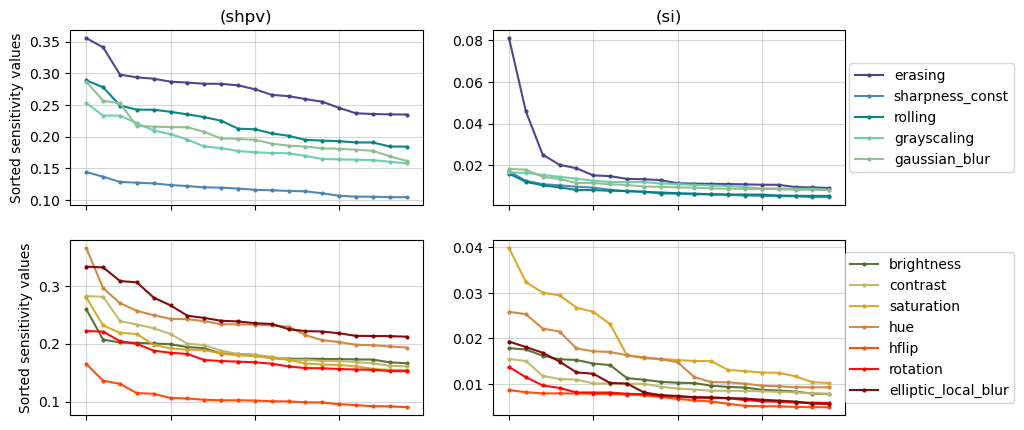

In [9]:
prediction.single_class.plot_top_sensitivity_values_decay(
    resnet18_loaded_sensitivity_values_dict_list,
    resnet18_classifying_layer_name,
    sensitivity_values_name_list,
    augmentation_set_numbers_list,
    n_top_values=n_top_values_decay_plot,
    figsize=figsize_decay_plot,
    extract_auxilliary_names=False,
    plot_colors=prediction.single_class._custom_colors[::-1],
    show=True,
)

### 2.3 Top sensitivity values and corresponding classes

[[$\leftarrow$Prev.subsect.]](#2.2-Decay-of-the-top-sensitivity-values)$\quad$[[Back to section]](#2.-ResNet18)$\quad$[[Next subsect.$\to$]](#2.4-Jaccard-indices-for-top-5-predictions-and-top-5-sensitive-classes)

In [11]:
resnet18_table_dict = prediction.single_class.extract_tables_top_sensitivity_values_decay(
    resnet18_loaded_sensitivity_values_dict_list,
    resnet18_classifying_layer_name,
    sensitivity_values_name_list,
    augmentation_set_numbers_list,
    places365_dataset.ind2class,
    n_top_values=10,
    extract_auxilliary_names=False,
)

In [12]:
for aug_name in augmentation_names:
    print(f'\n\t\t\t Augmentation: {aug_name}')
    display(resnet18_table_dict[aug_name])


			 Augmentation: erasing


shpv                                       si                         
  class_id                class_name value class_id            class_name   
0      185          ice_cream_parlor   .36      177          home_theater  \
1      204                    lagoon   .34      328       television_room   
2       13  archaelogical_excavation   .30      235  movie_theater indoor   
3      168          gymnasium indoor   .29      298           server_room   
4      105                    corral   .29       41              barndoor   
5      110                     creek   .29      340                trench   
6      210              lecture_room   .29      176           home_office   
7      353                water_park   .28      251                pagoda   
8      287                rice_paddy   .28      244                office   
9      165         greenhouse indoor   .28      299                  shed   

         
  value  
0   .08  
1   .05  
2   .03  
3   .02  
4   .02  
5   .02  
6   .01  
7   .01  
8   .01  
9   .01


			 Augmentation: sharpness_const


shpv                                   si                        
  class_id            class_name value class_id        class_name value
0      114          delicatessen   .14      171            harbor   .02
1      346  veterinarians_office   .14       91    church outdoor   .01
2      156         garage indoor   .13      159   gazebo exterior   .01
3      194                 islet   .13      130    elevator_lobby   .01
4      341                tundra   .13      330       temple asia   .01
5      358               wet_bar   .12       35          ballroom   .01
6      190               iceberg   .12      271              pond   .01
7      228             mezzanine   .12      345  vegetable_garden   .01
8      279            rainforest   .12      276           raceway   .01
9      204                lagoon   .12       32  balcony exterior   .01


			 Augmentation: rolling


...

shpv                                       si                       
  class_id                class_name value class_id       class_name value
0      283  residential_neighborhood   .17      197  japanese_garden   .01
1      364                zen_garden   .14      179    hospital_room   .01
2       85                  catacomb   .13      107          cottage   .01
3      119             diner outdoor   .11      223   market outdoor   .01
4      148                food_court   .11       10         aqueduct   .01
5      318              storage_room   .11      206         landfill   .01
6      348                   village   .11       12             arch   .01
7      221         manufactured_home   .10      280        reception   .01
8      238              music_studio   .10      234   mountain_snowy   .01
9       42            baseball_field   .10      182       hotel_room   .01


			 Augmentation: rotation


shpv                             si                           
  class_id      class_name value class_id           class_name value
0      244          office   .22      244               office   .01
1      348         village   .22      107              cottage   .01
2      242      oast_house   .20      345     vegetable_garden   .01
3      305       ski_slope   .20      149       football_field   .01
4      176     home_office   .19      147  florist_shop indoor   .01
5       14         archive   .18      197      japanese_garden   .01
6      357            wave   .18       83            carrousel   .01
7        7  amusement_park   .17      158          gas_station   .01
8      299            shed   .17      182           hotel_room   .01
9      336  train_interior   .17       84               castle   .01


			 Augmentation: elliptic_local_blur


shpv                                       si                         
  class_id                class_name value class_id         class_name value
0      170            hangar outdoor   .33      210       lecture_room   .02
1      116               desert sand   .33      363       youth_hostel   .02
2      117         desert vegetation   .31      179      hospital_room   .02
3      130            elevator_lobby   .31      120        dining_hall   .01
4      283  residential_neighborhood   .28      165  greenhouse indoor   .01
5      294                   sandbox   .27      272              porch   .01
6      240                   nursery   .25      300          shoe_shop   .01
7       54                 beer_hall   .24      183              house   .01
8      339                tree_house   .24       41           barndoor   .01
9      127                  driveway   .24       34           ball_pit   .01

### 2.4 Jaccard indices for top-5 predictions and top-5 sensitive classes

[[$\leftarrow$Prev.subsect.]](#2.3-Top-sensitivity-values-and-corresponding-classes)$\quad$[[Back to section]](#2.-ResNet18)$\quad$[[Next subsect.$\to$]](#2.5-Jaccard-indices-for-top-5-masked-predictions-and-top-5-sensitive-classes)

In [13]:
resnet18_sensitivity_topn_list = prediction.single_class.get_sensitivity_topn_dict(
    resnet18_loaded_sensitivity_values_dict_list,
    resnet18_classifying_layer_name,
    augmentation_set_numbers_list,
    top_n=5,
    extract_auxilliary_names=False,
)

resnet18_results_jacc_nofcl_list = []
resnet18_results_jacc_aug_no_mask_list = []
resnet18_results_jacc_orig_no_mask_list = []

for i in range(n_sens_vals):
    (
        resnet18_results_jacc,
        resnet18_results_jacc_aug_no_mask,
        resnet18_results_jacc_orig_no_mask,
    ) = prediction.single_class.extract_jaccard(
        prediction_results_path_nofcl_list[i],
        resnet18_sensitivity_topn_list[i],
        augmentation_names,
        no_aug_key=no_aug_key,
        y_true_key=y_true_key,
    )
    resnet18_results_jacc_nofcl_list.append(resnet18_results_jacc)
    resnet18_results_jacc_aug_no_mask_list.append(resnet18_results_jacc_aug_no_mask)
    resnet18_results_jacc_orig_no_mask_list.append(resnet18_results_jacc_orig_no_mask)

Nsamples=36500
Nsamples=36500


In [14]:
for i_val, val_name in enumerate(sensitivity_values_name_list):
    table_jac_no_masking = prediction.single_class.extract_table_no_masking(
        resnet18_results_jacc_aug_no_mask_list[i_val],
        resnet18_results_jacc_orig_no_mask_list[i_val],
        augmentation_set_numbers_list,
        extract_auxilliary_names=False,
        n_round_digits=n_round_digits,
        no_aug_key=no_aug_key,
    )
    print(f'\n\n\t\t\t\t{val_name}')
    display(table_jac_no_masking)



				shpv


SA variable used for extracting the most sensitive classes from the classifying layer   
                                                                                                    erasing   
Augmentation of input                                                                                         
original                                                          0.0076                                     \
erasing                                                           0.0057                                      
sharpness_const                                                   0.0072                                      
rolling                                                           0.0075                                      
grayscaling                                                       0.0065                                      
gaussian_blur                                                     0.0077                                      
brightness                                                        0.0069                                      
contrast                                                          0.0060                                      
saturation                                                        0.0067                                      
hue                                                               0.0056                                      
hflip                                                             0.0076                                      
rotation                                                          0.0083                                      
elliptic_local_blur                                               0.0076                                      

                                                                          
                      sharpness_const rolling grayscaling gaussian_blur   
Augmentation of input                                                     
original                       0.0077  0.0054      0.0054        0.0087  \
erasing                        0.0053  0.0048      0.0046        0.0087   
sharpness_const                0.0072  0.0054      0.0053        0.0085   
rolling                        0.0069  0.0058      0.0063        0.0086   
grayscaling                    0.0041  0.0042      0.0021        0.0067   
gaussian_blur                  0.0070  0.0054      0.0056        0.0088   
brightness                     0.0072  0.0060      0.0054        0.0094   
contrast                       0.0065  0.0070      0.0047        0.0078   
saturation                     0.0069  0.0062      0.0052        0.0104   
hue                            0.0059  0.0066      0.0058        0.0096   
hflip                          0.0077  0.0054      0.0054        0.0086   
rotation                       0.0079  0.0057      0.0061        0.0107   
elliptic_local_blur            0.0076  0.0053      0.0054        0.0088   

                                                                                
                      brightness contrast saturation     hue   hflip rotation   
Augmentation of input                                                           
original                  0.0085   0.0066     0.0057  0.0074  0.0073   0.0083  \
erasing                   0.0110   0.0050     0.0052  0.0057  0.0072   0.0113   
sharpness_const           0.0088   0.0064     0.0053  0.0073  0.0069   0.0085   
rolling                   0.0083   0.0067     0.0059  0.0077  0.0077   0.0083   
grayscaling               0.0113   0.0052     0.0039  0.0041  0.0068   0.0080   
gaussian_blur             0.0072   0.0059     0.0060  0.0079  0.0085   0.0087   
brightness                0.0081   0.0059     0.0053  0.0084  0.0070   0.0101   
contrast                  0.0084   0.0043     0.0043  0.0087  0.0068   0.0092   
saturation                0.0079   0.0054     0.0058  0.0075  0.0067   0.0075   
hue                       0.0077   0.0046     0.0036  0.0058  0.0061   0



				si


SA variable used for extracting the most sensitive classes from the classifying layer   
                                                                                                    erasing   
Augmentation of input                                                                                         
original                                                          0.0075                                     \
erasing                                                           0.0285                                      
sharpness_const                                                   0.0082                                      
rolling                                                           0.0078                                      
grayscaling                                                       0.0091                                      
gaussian_blur                                                     0.0066                                      
brightness                                                        0.0075                                      
contrast                                                          0.0095                                      
saturation                                                        0.0074                                      
hue                                                               0.0087                                      
hflip                                                             0.0076                                      
rotation                                                          0.0057                                      
elliptic_local_blur                                               0.0073                                      

                                                                          
                      sharpness_const rolling grayscaling gaussian_blur   
Augmentation of input                                                     
original                       0.0090  0.0080      0.0091        0.0086  \
erasing                        0.0077  0.0071      0.0079        0.0179   
sharpness_const                0.0092  0.0085      0.0087        0.0095   
rolling                        0.0088  0.0085      0.0092        0.0090   
grayscaling                    0.0089  0.0083      0.0043        0.0133   
gaussian_blur                  0.0083  0.0084      0.0103        0.0073   
brightness                     0.0087  0.0084      0.0096        0.0087   
contrast                       0.0099  0.0095      0.0079        0.0102   
saturation                     0.0091  0.0089      0.0127        0.0085   
hue                            0.0084  0.0113      0.0098        0.0102   
hflip                          0.0090  0.0080      0.0092        0.0086   
rotation                       0.0086  0.0094      0.0095        0.0069   
elliptic_local_blur            0.0089  0.0085      0.0093        0.0084   

                                                                                
                      brightness contrast saturation     hue   hflip rotation   
Augmentation of input                                                           
original                  0.0063   0.0088     0.0084  0.0089  0.0084   0.0101  \
erasing                   0.0058   0.0099     0.0096  0.0071  0.0067   0.0106   
sharpness_const           0.0057   0.0087     0.0081  0.0089  0.0082   0.0103   
rolling                   0.0062   0.0097     0.0093  0.0093  0.0083   0.0102   
grayscaling               0.0040   0.0067     0.0102  0.0044  0.0100   0.0083   
gaussian_blur             0.0077   0.0096     0.0108  0.0098  0.0077   0.0094   
brightness                0.0070   0.0085     0.0110  0.0098  0.0080   0.0102   
contrast                  0.0058   0.0087     0.0104  0.0103  0.0081   0.0102   
saturation                0.0086   0.0100     0.0111  0.0100  0.0082   0.0097   
hue                       0.0060   0.0104     0.0112  0.0142  0.0099   0

### 2.5 Jaccard indices for top-5 masked predictions and top-5 sensitive classes

[[$\leftarrow$Prev.subsect.]](#2.4-Jaccard-indices-for-top-5-predictions-and-top-5-sensitive-classes)$\quad$[[Back to section]](#2.-ResNet18)$\quad$

In [15]:
for i_val, val_name in enumerate(sensitivity_values_name_list):
    featured_measurements, _ = prediction.single_class.collect_featured_measurements_jac(
        resnet18_results_jacc_nofcl_list[i_val],
        augmentation_set_numbers_list,
        alphas,
        percentiles,
        inverts,
        no_aug_key=no_aug_key,
    )
    table = prediction.single_class.extract_table_self_masking(
        featured_measurements,
        augmentation_set_numbers_list,
        alphas,
        percentiles,
        inverts,
        n_round_digits=n_round_digits,
        extract_auxilliary_names=False,
    )
    print(f'\n\n\t\t\t\t{val_name}')
    display(table)



				shpv


Mask configuration (SA variable is the same as augmentation)   
                                                                         alpha=0.0   
                                                                             q=0.5   
Augmentation of input                                                                
erasing                                                           0.0000            \
sharpness_const                                                   0.0000             
rolling                                                           0.0000             
grayscaling                                                       0.0000             
gaussian_blur                                                     0.0003             
brightness                                                        0.0002             
contrast                                                          0.0002             
saturation                                                        0.0000             
hue                                                               0.0000             
hflip                                                             0.0000             
rotation                                                          0.0003             
elliptic_local_blur                                               0.0000             

                                                                          
                                                      alpha=0.5           
                        q=0.6   q=0.7   q=0.8   q=0.9     q=0.5   q=0.6   
Augmentation of input                                                     
erasing                0.0004  0.0034  0.0050  0.0055    0.0020  0.0033  \
sharpness_const        0.0000  0.0000  0.0001  0.0025    0.0019  0.0006   
rolling                0.0001  0.0039  0.0092  0.0077    0.0063  0.0096   
grayscaling            0.0000  0.0007  0.0025  0.0024    0.0013  0.0027   
gaussian_blur          0.0033  0.0128  0.0229  0.0165    0.0100  0.0099   
brightness             0.0000  0.0001  0.0077  0.0059    0.0026  0.0036   
contrast               0.0000  0.0000  0.0002  0.0051    0.0009  0.0011   
saturation             0.0001  0.0004  0.0026  0.0042    0.0010  0.0012   
hue                    0.0000  0.0050  0.0065  0.0067    0.0020  0.0058   
hflip                  0.0000  0.0002  0.0013  0.0046    0.0007  0.0026   
rotation               0.0061  0.0111  0.0126  0.0078    0.0087  0.0103   
elliptic_local_blur    0.0000  0.0000  0.0000  0.0040    0.0035  0.0003   

                                                                          
                                              alpha=1.5                   
                        q=0.7   q=0.8   q=0.9     q=0.5   q=0.6   q=0.7   
Augmentation of input                                                     
erasing                0.0048  0.0058  0.0065    0.0002  0.0002  0.0002  \
sharpness_const        0.0016  0.0037  0.0065    0.0003  0.0007  0.0011   
rolling                0.0101  0.0083  0.0067    0.0131  0.0117  0.0111   
grayscaling            0.0025  0.0022  0.0022    0.0001  0.0014  0.0029   
gaussian_blur          0.0103  0.0115  0.0118    0.0190  0.0196  0.0219   
brightness             0.0067  0.0087  0.0073    0.0002  0.0004  0.0010   
contrast               0.0023  0.0048  0.0057    0.0000  0.0000  0.0001   
saturation             0.0025  0.0042  0.0050    0.0020  0.0019  0.0024   
hue                    0.0067  0.0049  0.0063    0.0018  0.0015  0.0013   
hflip                  0.0048  0.0058  0.0074    0.0050  0.0054  0.0057   
rotation               0.0098  0.0089  0.0079    0.0036  0.0038  0.0041   
elliptic_local_blur    0.0015  0.0045  0.0071    0.0010  0.0007  0.0008   

                                                     
                                      inv=0   inv=1  
                        q=0.8   q=0.9                
Augmentation of input                                
erasing                0.00



				si


Mask configuration (SA variable is the same as augmentation)   
                                                                         alpha=0.0   
                                                                             q=0.5   
Augmentation of input                                                                
erasing                                                           0.0000            \
sharpness_const                                                   0.0000             
rolling                                                           0.0011             
grayscaling                                                       0.0000             
gaussian_blur                                                     0.0000             
brightness                                                        0.0063             
contrast                                                          0.0037             
saturation                                                        0.0000             
hue                                                               0.0004             
hflip                                                             0.0000             
rotation                                                          0.0000             
elliptic_local_blur                                               0.0000             

                                                                          
                                                      alpha=0.5           
                        q=0.6   q=0.7   q=0.8   q=0.9     q=0.5   q=0.6   
Augmentation of input                                                     
erasing                0.0000  0.0001  0.0006  0.0026    0.0008  0.0010  \
sharpness_const        0.0002  0.0001  0.0004  0.0051    0.0072  0.0048   
rolling                0.0045  0.0060  0.0124  0.0133    0.0324  0.0273   
grayscaling            0.0000  0.0001  0.0028  0.0049    0.0008  0.0013   
gaussian_blur          0.0001  0.0006  0.0007  0.0035    0.0011  0.0022   
brightness             0.0007  0.0003  0.0037  0.0161    0.0039  0.0061   
contrast               0.0335  0.0387  0.0505  0.0363    0.0220  0.0238   
saturation             0.0000  0.0019  0.0028  0.0026    0.0328  0.0240   
hue                    0.0025  0.0064  0.0027  0.0037    0.0051  0.0053   
hflip                  0.0000  0.0001  0.0001  0.0044    0.0005  0.0025   
rotation               0.1280  0.1186  0.1125  0.0694    0.0057  0.0457   
elliptic_local_blur    0.0009  0.0037  0.0126  0.0069    0.0032  0.0081   

                                                                          
                                              alpha=1.5                   
                        q=0.7   q=0.8   q=0.9     q=0.5   q=0.6   q=0.7   
Augmentation of input                                                     
erasing                0.0015  0.0025  0.0042    0.0249  0.0316  0.0334  \
sharpness_const        0.0056  0.0071  0.0087    0.0096  0.0093  0.0095   
rolling                0.0222  0.0167  0.0116    0.0065  0.0091  0.0081   
grayscaling            0.0024  0.0036  0.0047    0.0030  0.0028  0.0032   
gaussian_blur          0.0043  0.0050  0.0054    0.0119  0.0143  0.0135   
brightness             0.0112  0.0144  0.0112    0.0004  0.0004  0.0007   
contrast               0.0226  0.0202  0.0156    0.0006  0.0007  0.0008   
saturation             0.0137  0.0055  0.0054    0.0452  0.0638  0.0764   
hue                    0.0041  0.0039  0.0048    0.0570  0.0749  0.0829   
hflip                  0.0040  0.0065  0.0078    0.0017  0.0038  0.0085   
rotation               0.0414  0.0275  0.0120    0.0048  0.0055  0.0059   
elliptic_local_blur    0.0096  0.0075  0.0070    0.0023  0.0044  0.0045   

                                                       
                                        inv=0   inv=1  
                        q=0.8   q=0.9                  
Augmentation of input                                  
erasing            